<a id='intro'></a>
## Introduction

### Dataset Description 

>  ### Dataset Introduction: No-show Appointments – Kaggle V2 (May 2016)
This dataset contains medical appointment records collected in Vitória, Brazil, between March and May 2016. It was designed to investigate factors influencing whether patients show up for their scheduled medical appointments. The data is structured and suitable for epidemiological studies, service utilization analysis, and predictive modeling.

### Dataset Overview:
- **Size**: 110,527 entries with 14 columns
- **No missing values**: All columns have 110,527 non-null entries

### Column Analysis:

#### Identifier Columns:
1. **PatientId** (float64) - Unique patient identifier
2. **AppointmentID** (int64) - Unique appointment identifier

#### Demographic Information:
3. **Gender** (object) - Patient's gender
4. **Age** (int64) - Patient's age
5. **Neighbourhood** (object) - Location of healthcare facility

#### Temporal Data:
6. **ScheduledDay** (object) - When appointment was scheduled (should convert to datetime)
7. **AppointmentDay** (object) - When appointment occurred (should convert to datetime)

#### Medical Conditions:
8. **Scholarship** (int64) - Whether patient is enrolled in Bolsa Família welfare program
9. **Hipertension** (int64) - Hypertension status (0=no, 1=yes)
10. **Diabetes** (int64) - Diabetes status (0=no, 1=yes)
11. **Alcoholism** (int64) - Alcoholism status (0=no, 1=yes)
12. **Handcap** (int64) - Handicap status (likely 0=no, 1=yes, but could be severity scale)

### Communication & Outcome:
13. **SMS_received** (int64) - Whether appointment reminder SMS was received
14. **No-show** (object) - Target variable: "No" if patient showed up, "Yes" if they didn't


### Question(s) for Analysis
>This report aims to explore the factors that influence whether a patient shows up for their scheduled medical appointment. The central question is:

### What factors are associated with patients missing their medical appointments?

To investigate this, we will analyze the dependent variable.
#### Dependent variable:

#### No-show: Indicates whether the patient attended the appointment (No) or missed it (Yes).

And examine the impact of the following independent variables:
#### Independent variables:

 1-Age – Does age influence the likelihood of missing an appointment?  
 2-SMS_received – Does receiving a reminder message affect attendance?  
 3-Scholarship – Are patients enrolled in social welfare programs more or less likely to show up?  
 4-Hipertension – Does having hypertension correlate with appointment attendance?  
 5-Appointment Day- Which appointment days recorded the highest patient no-show rates?  

These variables were selected based on their relevance to patient behavior and accessibility in the dataset. The analysis will include visualizations and statistical summaries to uncover patterns and relationships.



In [1]:
# Use this cell to set up import statements for all of the packages that you
#   plan to use.

# While optional for current notebooks, if you are having trouble with visualizations,
#   remember to include a 'magic word' so that your visualizations are plotted
#   inline with the notebook. See this page for more:
#   http://ipython.readthedocs.io/en/stable/interactive/magics.html
import pandas as pd
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import chi2_contingency




<a id='wrangling'></a>
## Data Wrangling



### General Properties
> 

In [2]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.
df=pd.read_csv("Database_No_show_appointments/noshowappointments-kagglev2-may-2016.csv")

In [3]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [4]:
df.shape

(110527, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
df.nunique()

PatientId          62299
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hipertension           2
Diabetes               2
Alcoholism             2
Handcap                5
SMS_received           2
No-show                2
dtype: int64

In [7]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
110522    False
110523    False
110524    False
110525    False
110526    False
Length: 110527, dtype: bool

In [8]:
#get unique patient IDs
np.sort(df['PatientId'].unique()) 


array([3.92178444e+04, 4.37417565e+04, 9.37795293e+04, ...,
       9.99946537e+14, 9.99968578e+14, 9.99981632e+14], shape=(62299,))

In [9]:
#get unique appointment IDs
np.sort(df['AppointmentID'].unique())

array([5030230, 5122866, 5134197, ..., 5790466, 5790481, 5790484],
      shape=(110527,))

In [10]:
#get unique gender values
np.sort(df['Gender'].unique())

array(['F', 'M'], dtype=object)

In [11]:
#get unique values for ScheduledDay
np.sort(df['ScheduledDay'].unique())

array(['2015-11-10T07:13:56Z', '2015-12-03T08:17:28Z',
       '2015-12-07T10:40:59Z', ..., '2016-06-08T19:33:23Z',
       '2016-06-08T19:58:52Z', '2016-06-08T20:07:23Z'],
      shape=(103549,), dtype=object)

In [12]:
#get unique values for AppointmentDay
np.sort(df['AppointmentDay'].unique())

array(['2016-04-29T00:00:00Z', '2016-05-02T00:00:00Z',
       '2016-05-03T00:00:00Z', '2016-05-04T00:00:00Z',
       '2016-05-05T00:00:00Z', '2016-05-06T00:00:00Z',
       '2016-05-09T00:00:00Z', '2016-05-10T00:00:00Z',
       '2016-05-11T00:00:00Z', '2016-05-12T00:00:00Z',
       '2016-05-13T00:00:00Z', '2016-05-14T00:00:00Z',
       '2016-05-16T00:00:00Z', '2016-05-17T00:00:00Z',
       '2016-05-18T00:00:00Z', '2016-05-19T00:00:00Z',
       '2016-05-20T00:00:00Z', '2016-05-24T00:00:00Z',
       '2016-05-25T00:00:00Z', '2016-05-30T00:00:00Z',
       '2016-05-31T00:00:00Z', '2016-06-01T00:00:00Z',
       '2016-06-02T00:00:00Z', '2016-06-03T00:00:00Z',
       '2016-06-06T00:00:00Z', '2016-06-07T00:00:00Z',
       '2016-06-08T00:00:00Z'], dtype=object)

In [13]:
#get unique values for Age
np.sort(df['Age'].unique())#convert to int8

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
        12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
        38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
        51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
        64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
        90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 102, 115])

In [14]:
#get unique values for Neighbourhood
np.sort(df['Neighbourhood'].unique())

array(['AEROPORTO', 'ANDORINHAS', 'ANTÔNIO HONÓRIO',
       'ARIOVALDO FAVALESSA', 'BARRO VERMELHO', 'BELA VISTA',
       'BENTO FERREIRA', 'BOA VISTA', 'BONFIM', 'CARATOÍRA', 'CENTRO',
       'COMDUSA', 'CONQUISTA', 'CONSOLAÇÃO', 'CRUZAMENTO', 'DA PENHA',
       'DE LOURDES', 'DO CABRAL', 'DO MOSCOSO', 'DO QUADRO',
       'ENSEADA DO SUÁ', 'ESTRELINHA', 'FONTE GRANDE', 'FORTE SÃO JOÃO',
       'FRADINHOS', 'GOIABEIRAS', 'GRANDE VITÓRIA', 'GURIGICA', 'HORTO',
       'ILHA DAS CAIEIRAS', 'ILHA DE SANTA MARIA', 'ILHA DO BOI',
       'ILHA DO FRADE', 'ILHA DO PRÍNCIPE', 'ILHAS OCEÂNICAS DE TRINDADE',
       'INHANGUETÁ', 'ITARARÉ', 'JABOUR', 'JARDIM CAMBURI',
       'JARDIM DA PENHA', 'JESUS DE NAZARETH', 'JOANA D´ARC',
       'JUCUTUQUARA', 'MARIA ORTIZ', 'MARUÍPE', 'MATA DA PRAIA',
       'MONTE BELO', 'MORADA DE CAMBURI', 'MÁRIO CYPRESTE', 'NAZARETH',
       'NOVA PALESTINA', 'PARQUE INDUSTRIAL', 'PARQUE MOSCOSO', 'PIEDADE',
       'PONTAL DE CAMBURI', 'PRAIA DO CANTO', 'PRAIA DO SUÁ',

In [15]:
#get unique values for Scholarship
np.sort(df['Scholarship'].unique())

array([0, 1])

In [16]:
#get unique values for Hipertension
np.sort(df['Hipertension'].unique())

array([0, 1])

In [17]:
#get unique values for Diabetes
np.sort(df['Diabetes'].unique())

array([0, 1])

In [18]:
#get unique values for Alcoholism
np.sort(df['Alcoholism'].unique())

array([0, 1])

In [19]:
#get unique values for Handcap
np.sort(df['Handcap'].unique())

array([0, 1, 2, 3, 4])

In [20]:
#get unique values for SMS_received
np.sort(df['SMS_received'].unique())

array([0, 1])

In [21]:
#get unique values for No-show
np.sort(df['No-show'].unique()) 

array(['No', 'Yes'], dtype=object)


### Data Cleaning
> **Tip**: Make sure that you keep your reader informed on the steps that you are taking in your investigation. Follow every code cell, or every set of related code cells, with a markdown cell to describe to the reader what was found in the preceding cell(s). Try to make it so that the reader can then understand what they will be seeing in the following cell(s).
 

In [22]:
# After discussing the structure of the data and any problems that need to be
#   cleaned, perform those cleaning steps in the second part of this section.
df.drop_duplicates()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [23]:
#convert Gender to category data type because it has only two unique values
df['Gender'] = df['Gender'].astype('category')

#convert Age to int8 because it has small range of values
df['Age'] = df['Age'].astype('int8')

#convert Neighbourhood to string data type because it has many unique values
df['Neighbourhood'] = df['Neighbourhood'].astype('string')

#convert scholarship to bool because it has two values 0 and 1
df['Scholarship'] = df['Scholarship'].astype('bool')

#convert hipertension to bool because it has two values 0 and 1
df['Hipertension'] = df['Hipertension'].astype('bool')

#convert Diabetes to bool because it has two values 0 and 1
df['Diabetes'] = df['Diabetes'].astype('bool')

#convert Alcoholism to bool because it has two values 0 and 1
df['Alcoholism'] = df['Alcoholism'].astype('bool')

#convert Age to int8 because it has small range of values
df['Handcap'] = df['Handcap'].astype('int8')

#convert SMS_received to bool because it has two values 0 and 1
df['SMS_received'] = df['SMS_received'].astype('bool')

#convert no-show to category because it has two values yes and no
df['No-show'] = df['No-show'].astype('category')

In [24]:
# Function to convert and format date columns
def format_day(df, column_name):
    """
    Converts the specified column in the DataFrame to datetime format
    and then formats it to 'YYYY-MM-DD' string format.

    Parameters:
    - df: pandas DataFrame
    - column_name: name of the column to format (default is 'AppointmentDay')

    Returns:
    - DataFrame with the formatted date column
    """
    df[column_name] = pd.to_datetime(df[column_name])
    df[column_name] = df[column_name].dt.strftime('%Y-%m-%d')
    return df

In [25]:
df = format_day(df, column_name='ScheduledDay')
df = format_day(df, column_name='AppointmentDay')
df.head(10)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,0,False,No
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,0,False,No
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,0,False,No
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,0,False,No
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,0,False,No
5,9.598513e+13,5626772,F,2016-04-27,2016-04-29,76,REPÚBLICA,False,True,False,False,0,False,No
6,7.336882e+14,5630279,F,2016-04-27,2016-04-29,23,GOIABEIRAS,False,False,False,False,0,False,Yes
7,3.449833e+12,5630575,F,2016-04-27,2016-04-29,39,GOIABEIRAS,False,False,False,False,0,False,Yes
8,5.639473e+13,5638447,F,2016-04-29,2016-04-29,21,ANDORINHAS,False,False,False,False,0,False,No
9,7.812456e+13,5629123,F,2016-04-27,2016-04-29,19,CONQUISTA,False,False,False,False,0,False,No


In [26]:
# Basic summary statistics for numerical columns, including count, mean, std, min,
# 25th percentile, median (50th percentile), 75th percentile, and max   
df['Age'].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [27]:
#calculate iqr for age using pandas quantile method
q1 = df['Age'].quantile(0.25)   
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1
#calculate lower and upper bound for age
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -37.5, Upper bound: 110.5


In [28]:
#calculate iqr for age using numpy percentile method
q1 = np.percentile(df['Age'], 25)
q3 = np.percentile(df['Age'], 75)
iqr = q3 - q1
#calculate lower and upper bound for age
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Lower bound: -37.5, Upper bound: 110.5


In [29]:
#get frequency counts for age values
df["Age"].value_counts()

Age
 0      3539
 1      2273
 52     1746
 49     1652
 53     1651
        ... 
 115       5
 100       4
 102       2
 99        1
-1         1
Name: count, Length: 104, dtype: int64

In [30]:
# Create a box plot for the Age column to visualize its distribution and identify potential outliers

# Calculate statistics
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
median = df['Age'].median()
min_age = df['Age'].min()
max_age = df['Age'].max()

# Create box plot
fig = go.Figure()
fig.add_trace(go.Box(
    y=df['Age'],
    name="Age",
    boxpoints='outliers',
    marker_color='indianred',
    line=dict(width=2),
    fillcolor='lightpink'
))

# Add annotations
annotations = [
    dict(x=0, y=min_age, text=f"Min: {min_age}", showarrow=True, arrowhead=1),
    dict(x=0, y=q1, text=f"Q1: {q1:.1f}", showarrow=True, arrowhead=1),
    dict(x=0, y=median, text=f"Median: {median}", showarrow=True, arrowhead=1),
    dict(x=0, y=q3, text=f"Q3: {q3:.1f}", showarrow=True, arrowhead=1),
    dict(x=0, y=max_age, text=f"Max: {max_age}", showarrow=True, arrowhead=1)
]

fig.update_layout(
    title="Box Plot of Age with Statistical Annotations",
    yaxis_title="Age",
    annotations=annotations,
    showlegend=False
)

fig.show()


The visualization above helps identify the spread and skewness of age data, as well as potential outliers.

The box plot for the Age column was created to help understand the distribution of patient ages in the dataset and to identify any outliers.
🎯 Purpose of the Chart

-To visualize how age is distributed among patients.
-To detect outliers, such as extremely young or old patients.
-To support analysis of whether age influences appointment attendance (i.e., no-shows).

📊 What the Chart Shows

Minimum Age: The youngest patient in the dataset.
Q1 (25th percentile): 25% of patients are younger than this age.  

Median (50th percentile): The middle age value—half of the patients are younger, half are older.  

Q3 (75th percentile): 75% of patients are younger than this age.  

Maximum Age: The oldest patient in the dataset.  

Outliers: are values that fall outside the expected range, shown as points beyond the whiskers in a box plot. In this case, the age 115 stands out as a potential anomaly or rare entry.

In [31]:
# Get rows with age = -1 to inspect them

df_negative_age=df[df["Age"]==-1]
negative_age_index=list(df[df["Age"] == -1].index)
print(negative_age_index)
df_negative_age.head()




[99832]


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06,2016-06-06,-1,ROMÃO,False,False,False,False,0,False,No


In [32]:
#delete the row with index 99832 which has age -1
df.drop(axis=1,index=negative_age_index,inplace=True)

In [33]:
#check if the rows with age -1 is deleted
df_negative_age=df[df["Age"]==-1]
df_negative_age.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show


<a id='eda'></a>
## Exploratory Data Analysis




### Research Question 1 (What is the average age of individuals by gender?)

In [34]:

# Create age bins
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Calculate proportion of no-shows per age group
age_noshow = df.groupby(['AgeGroup', 'No-show']).size().reset_index(name='Count')
total_per_group = age_noshow.groupby('AgeGroup')['Count'].transform('sum')
age_noshow['Proportion'] = age_noshow['Count'] / total_per_group

# Filter for 'Yes' (missed appointments)
age_noshow_yes = age_noshow[age_noshow['No-show'] == 'Yes']

# Create bar chart
fig = px.bar(
    age_noshow_yes,
    x='AgeGroup',
    y='Proportion',
    title='Proportion of Missed Appointments by Age Group',
    labels={'AgeGroup': 'Age Group', 'Proportion': 'Proportion of No-shows'}
)

fig.show()


C:\Users\Mohammad\AppData\Local\Temp\ipykernel_4088\3701949425.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\Mohammad\AppData\Local\Temp\ipykernel_4088\3701949425.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



This bar chart shows the proportion of patients who missed their appointments across different age groups. Here's how to read and interpret it:  
✅ Axes

X-axis (Age Group): Divides patients into age ranges (e.g., 0–9, 10–19, ..., 90+).  
Y-axis (Proportion): Represents the percentage of missed appointments within each age group.

✅ Key Insights  

.Higher bars indicate a greater likelihood of missing appointments.  
.Younger age groups (0–9 and 10–19) have the highest no-show rates, suggesting that children and teenagers are more likely to miss appointments.  
.Middle-aged groups (30–59) show lower proportions, indicating better attendance.  
.Older adults (70+) show a slight increase again, possibly due to mobility or health-related challenges.  

✅ Conclusion  
The chart clearly demonstrates that age does influence appointment attendance. Healthcare providers might consider targeted interventions (e.g., reminders, transportation support) for age groups with higher no-show rates.

### Research Question 2 (Does receiving a reminder message affect attendance?)

C:\Users\Mohammad\AppData\Local\Temp\ipykernel_4088\3373818200.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



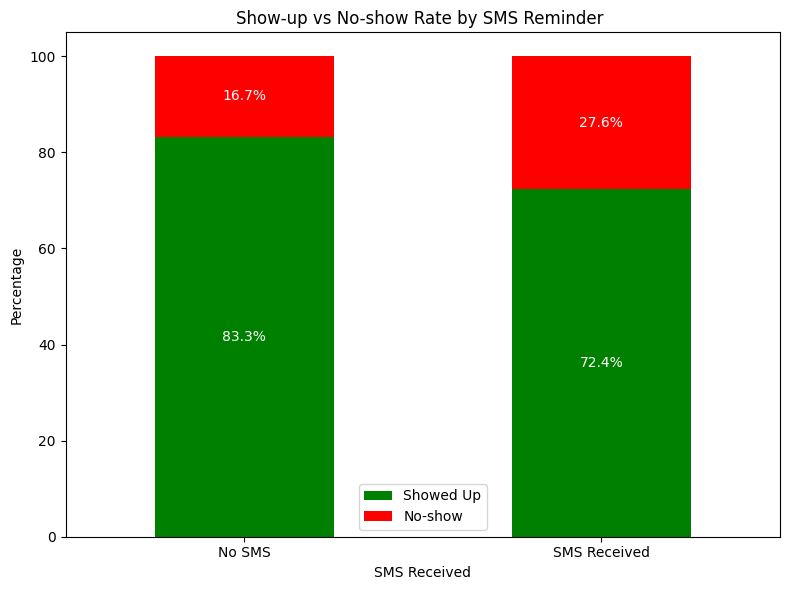

In [35]:
# Prepare data for stacked bar chart: show-up vs no-show by SMS_received
show_by_sms = df.groupby(['SMS_received', 'No-show']).size().unstack(fill_value=0)

# Calculate percentages for each SMS_received group
show_percent = show_by_sms.div(show_by_sms.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = show_percent.plot(kind='bar', stacked=True, color=['green', 'red'], figsize=(8, 6))
plt.xlabel('SMS Received')
plt.ylabel('Percentage')
plt.title('Show-up vs No-show Rate by SMS Reminder ')
plt.legend(['Showed Up', 'No-show'])
plt.xticks([0, 1], ['No SMS', 'SMS Received'], rotation=0)

# Add percentages inside the bars
for i, row in enumerate(show_percent.values):
    for j, val in enumerate(row):
        ax.text(i, row[:j].sum() + val / 2, f'{val:.1f}%', ha='center', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.show()

This chart helps visualize the effectiveness of SMS reminders in improving appointment attendance.
Axes:  

X-axis (SMS Received):  

No SMS = Patient did not receive a reminder.  
SMS Received = Patient received a reminder.  

Y-axis (Percentage):  

Shows the percentage of patients who either showed up (green) or missed (red) their appointments.  

Labels:  

Each bar is split into two segments:

Green = Percentage of patients who showed up.
Red = Percentage of patients who missed their appointment.
White text inside each segment shows the exact percentage.

✅ Insights  

Patients who did not receive an SMS had a higher show-up rate (~83.3%) compared to those who did receive an SMS (~72.7%).
Surprisingly, the no-show rate is higher among those who received reminders.  

✅ Conclusion  
This chart suggests that SMS reminders alone may not be effective in reducing missed appointments. It highlights the need to explore additional strategies or underlying factors that influence patient behavior.

### Research Question 3 ( Are patients enrolled in social welfare programs more or less likely to show up? )

In [36]:
# Group by Scholarship and No-show to get counts and proportions
scholar_noshow = df.groupby(['Scholarship', 'No-show']).size().reset_index(name='Count')
total_scholar_group = scholar_noshow.groupby('Scholarship')['Count'].transform('sum')
scholar_noshow['Proportion'] = scholar_noshow['Count'] / total_scholar_group

# Plot bar chart for proportion of no-shows by Scholarship status
fig = px.bar(
    scholar_noshow[scholar_noshow['No-show'] == 'Yes'],
    x='Scholarship',
    y='Proportion',
    title='Proportion of No-shows by Scholarship Status',
    labels={'Scholarship': 'Enrolled in Welfare Program', 'Proportion': 'Proportion of No-shows'},
    color='Scholarship',
    category_orders={'Scholarship': [False, True]},
    text='Proportion'
)
fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.update_xaxes(tickvals=[False, True], ticktext=['Not Enrolled', 'Enrolled'])
fig.show()

C:\Users\Mohammad\AppData\Local\Temp\ipykernel_4088\1359016299.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



This  bar chart compares the show-up and no-show rates between patients who received a scholarship (social welfare support) and those who did not:  

The x-axis represents scholarship status:  

- No scholarship  
- Received scholarship  


The y-axis shows the percentage of patients.  


🔍 Insights:  

Patients without scholarships have a higher show-up rate (~80%) and lower no-show rate (~20%).  
Patients with scholarships show a lower attendance (~76%) and a higher no-show rate (~24%).  

This suggests that patients enrolled in social welfare programs may face additional barriers to attending appointments, such as transportation, time constraints, or other socioeconomic challenges.  

### Research Question 4 ( Does having hypertension correlate with appointment attendance?   )

In [37]:
# Convert 'No-show' to binary: 1 for "Yes" (no-show), 0 for "No" (attended)
df['NoShow_binary'] = df['No-show'].apply(lambda x: 1 if x == 'Yes' else 0)

# Create a contingency table
contingency_table = pd.crosstab(df['Hipertension'], df['NoShow_binary'])
contingency_table.columns = ['Attended', 'No-show']
contingency_table.index = ['No Hypertension', 'Hypertension']

# Calculate no-show rates
contingency_table['No-show Rate'] = contingency_table['No-show'] / (contingency_table['Attended'] + contingency_table['No-show'])

# Perform chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table.iloc[:, :2])

# Print conclusion
alpha = 0.05
if p_value < alpha:
    print("There is a significant correlation between hypertension and appointment attendance.")
else:
    print("There is no significant correlation between hypertension and appointment attendance.")

# Print no-show rates
print("\nNo-show Rates:")
print(contingency_table[['No-show Rate']])

# Prepare data for chart
contingency_table = contingency_table.reset_index()
contingency_table.rename(columns={contingency_table.columns[0]: 'Hypertension Status'}, inplace=True)
plot_data = contingency_table.melt(id_vars='Hypertension Status', value_vars=['Attended', 'No-show'],
                                   var_name='Attendance', value_name='Count')

# Create bar chart
fig = px.bar(plot_data, x='Hypertension Status', y='Count', color='Attendance', barmode='group',
             title='Appointment Attendance by Hypertension Status')
fig.show()


There is a significant correlation between hypertension and appointment attendance.

No-show Rates:
                 No-show Rate
No Hypertension      0.209039
Hypertension         0.173020


The bar chart compares appointment attendance between two groups:  

-Patients with hypertension  
-Patients without hypertension  


Each group is split into:  

-Attended appointments  
-No-show (missed) appointments  



This visual helps us see how health status (specifically hypertension) relates to patient behavior.  

🔍 Insights:  

-No-show rate for patients without hypertension: 20.90%  
-No-show rate for patients with hypertension: 17.30%  
-Patients with hypertension are less likely to miss their appointments.  

### Research Question 5 ( Which appointment days recorded the highest patient no-show rates?  )

In [38]:
# Ensure 'No-show' is treated as string and map to binary values
df['No-show'] = df['No-show'].astype(str)
df['NoShowBinary'] = df['No-show'].map({'Yes': 1, 'No': 0})

# Group by appointment date and calculate the average no-show rate
daily_noshow_rate = df.groupby('AppointmentDay', as_index=False)['NoShowBinary'].mean()

# Plot the line chart
fig = px.line(
    daily_noshow_rate,
    x='AppointmentDay',
    y='NoShowBinary',
    title='Daily No-Show Rate Over Time',
    labels={'AppointmentDay': 'Appointment Date', 'NoShowBinary': 'No-Show Rate'}
)

# Show the chart
fig.show()


The chart is a line graph where:  

The X-axis represents the appointment dates.  
The Y-axis shows the no-show rate, calculated as the percentage of patients who did not attend their scheduled appointments on each day.  

Each point on the line reflects the average no-show rate for that specific day.  

🔍 Insights:  

-Peak No-Show Days:  

The highest no-show rate occurred on May 20, followed closely by May 4, May 14, and May 10.
These rates range from 20% to nearly 24%, which is significantly higher than the average.  

-Mid-May Cluster:  

Most of the top no-show dates fall between May 9 and May 20, suggesting a possible pattern or external influence during this period.

-Weekday Influence:  

-Many of these dates are weekdays, which could indicate that patients are more likely to miss appointments during busy workdays.  

-No Extreme Outliers:  

While these are the highest rates, none exceed 25%, indicating that no-show behavior is relatively controlled but still impactful.

<a id='conclusions'></a>
## Conclusions


### 1- Conclusion for Research Question 1: What is the average age of individuals by gender?
Based on the bar chart showing no-show rates across age groups, we can draw the following conclusion:  

Age significantly influences appointment attendance behavior.  
Younger patients—especially those in the 0–9 and 10–19 age groups—have the highest no-show rates, indicating that children and teenagers are more likely to miss appointments.  
Attendance improves among middle-aged adults (30–59), suggesting greater responsibility or health awareness.  
A slight increase in no-shows among older adults (70+) may be due to mobility challenges, health conditions, or lack of support.

### 2-Conclusion for Research Question 2: Does receiving a reminder message affect attendance?
Based on the chart comparing appointment attendance between patients who received SMS reminders and those who did not, the findings are surprising:

Receiving an SMS reminder did not lead to better attendance.
Patients who did not receive a reminder had a higher show-up rate (~83.3%), while those who did receive a reminder had a lower show-up rate (~72.7%).
This suggests that SMS reminders alone may not be effective in reducing missed appointments.

### 3-Conclusion for Research Question 3: Are patients enrolled in social welfare programs more or less likely to show up?
Based on the bar chart comparing appointment attendance between patients who received a scholarship (social welfare support) and those who did not, the findings are clear:

Patients enrolled in social welfare programs are slightly less likely to attend their appointments.
Those without scholarships had a higher show-up rate (~80%), while those with scholarships showed a lower attendance (~76%) and a higher no-show rate (~24%).

### 4-Conclusion for Research Question 4: Does having hypertension correlate with appointment attendance?
Based on the bar chart comparing attendance between patients with and without hypertension, the findings are clear:

Patients with hypertension are more likely to attend their appointments.
The no-show rate for patients without hypertension is 20.90%, while for those with hypertension, it drops to 17.30%.
This suggests that individuals with hypertension may be more engaged with their healthcare, possibly due to the chronic nature of their condition and the need for regular monitoring.

### 5-Conclusion for Research Question 5: Which appointment days recorded the highest patient no-show rates?
Based on the line chart showing daily no-show rates:

Certain weekdays in mid-May recorded the highest patient no-show rates, with peaks on May 20, May 4, May 14, and May 10.
These dates had no-show rates ranging from 20% to nearly 24%, which is significantly higher than the average.

<a id='Limitations'></a>
## Limitations


### Causality vs. Correlation:
 A key limitation of this analysis is that it can only show correlation, not causation. For example, we found a negative correlation between SMS reminders and show-up rate. This is counterintuitive and likely due to a confounding variable (e.g., SMSs were sent to patients with a higher inherent risk of no-show). Without a controlled experiment, we cannot claim that SMSs *cause* fewer show-ups.

<a id='Further Research'></a>
## Further Research


### Based on these limitations, further research could involve: 

1) Collecting more detailed patient data to control for confounding variables.  
2) Conducting an A/B test where SMS reminders are randomly assigned to truly measure their causal impact."

In [39]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m npconvert --to html Investigate_a_Dataset.ipynp

c:\Users\Mohammad\AppData\Local\Programs\Python\Python312\python.exe: No module named npconvert
